# Co-Recall by Lag

> Compute and visualize joint co-recall probability as a function of study lag.

Co-recall by lag (CoRec) estimates the probability that two study positions separated by lag $d$ are both recalled on the same trial, ignoring recall order. For each positive lag, the analysis counts the number of co-recalled pairs and divides by the total number of pairs at that lag.

$$\text{CoRec}(d) = \frac{\sum_t \text{co-recalled pairs at lag } d}{\sum_t \text{possible pairs at lag } d}$$

Unlike conditional co-recall, the denominator here is the total number of possible pairs at each lag regardless of whether the anchor was recalled. This makes CoRec a joint probability measure rather than a conditional one.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |
| `max_lag` | Maximum lag to display |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.joint_corec_by_lag import (
    corec_by_lag,
    plot_corec_by_lag,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "CoRecByLag"
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['list_type'] == 1"
max_lag = 5

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

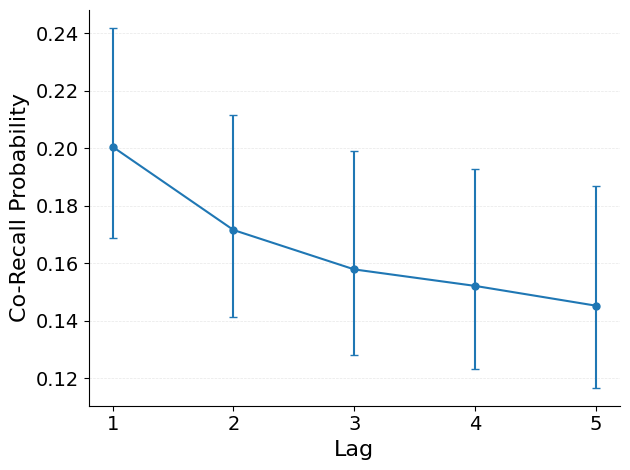

In [5]:
#| code-summary: Plot co-recall by lag
#| label: fig-corec-by-lag
#| fig-cap: "Co-recall probability as a function of study lag."
plot_corec_by_lag(data, trial_mask, max_lag=max_lag)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

Each dataset is paired with its corresponding mask by index. To compare conditions within one dataset, pass the dataset multiple times with different masks: `plot_corec_by_lag([data, data], [mask_a, mask_b], ...)`.

In [6]:
#| echo: false
show_doc(plot_corec_by_lag)

---

### plot_corec_by_lag

>      plot_corec_by_lag (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],j
>                         axcmr.typing.RecallDataset], trial_masks:Union[Sequenc
>                         e[jaxtyping.Bool[Array,'trial_count']],jaxtyping.Bool[
>                         Array,'trial_count']], max_lag:Optional[int]=None,
>                         color_cycle:Optional[list[str]]=None,
>                         labels:Optional[Sequence[str]]=None,
>                         contrast_name:Optional[str]=None,
>                         axis:Optional[matplotlib.axes._axes.Axes]=None,
>                         confidence_level:float=0.95)

*Plot co-recall curves with confidence intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Dataset or list of datasets to plot. |
| trial_masks | Union |  | Boolean masks selecting trials within each<br>dataset. |
| max_lag | Optional | None | Maximum lag to display (defaults to full<br>range). |
| color_cycle | Optional | None | Colors for plotting each dataset. |
| labels | Optional | None | Legend labels for each dataset. |
| contrast_name | Optional | None | Legend title for contrasts. |
| axis | Optional | None | Existing Matplotlib ``Axes`` to plot on. |
| confidence_level | float | 0.95 | Confidence level for the bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with co-recall curves.** |

The `plot_corec_by_lag` function uses `corec_by_lag` internally, which aggregates trial-level co-recall counts across the dataset.

In [7]:
#| echo: false
show_doc(corec_by_lag)

---

### corec_by_lag

>      corec_by_lag (dataset:jaxcmr.typing.RecallDataset)

*Return CoRec(d) for positive lags.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset containing ``recalls`` and<br>``pres_itemnos``. |
| **Returns** | **Float[Array, 'lags']** | **Co-recall probability at each positive lag.** |

In [8]:
# Positions 1 and 2 recalled out of 3: lag-1 joint prob is 0.5
recalls = jnp.array([[1, 2, 0]], dtype=jnp.int32)
presentations = jnp.array([[1, 2, 3]], dtype=jnp.int32)

dataset = {
    "subject": jnp.ones((1, 1), dtype=jnp.int32),
    "listLength": jnp.full((1, 1), 3, dtype=jnp.int32),
    "pres_itemnos": presentations,
    "recalls": recalls,
}

result = corec_by_lag(dataset)
assert float(result[0]) == 0.5